# 합성곱 신경망을 사용한 이미지 분류


## Exp 15 - Lightweight 3 Conv Layers + Dense 64

- 변경 내용: Conv block을 3개로 늘리고 Dense layer를 64 units로 줄인다.
- 실험 목적: 3번째 Conv/Pooling으로 feature map 크기를 줄이고 Dense(64)를 사용하여 전체 파라미터 수를 줄이는 경량화 조합의 성능을 확인한다.
- 비교 기준: 동일한 데이터 분할, 동일한 seed, 동일한 최대 epoch/early stopping 조건을 사용한다.
- 조합 근거: Conv 3 layers는 feature map을 더 작게 만들어 Dense 입력을 줄였고, Dense(64)는 단일 실험에서 적은 파라미터로 Baseline 수준의 성능을 보였다. 두 설정을 결합하여 경량 모델을 구성한다.



In [21]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/hg-mldl2/blob/main/08-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>


In [22]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
import keras
import tensorflow as tf

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()


## 패션 MNIST 데이터 불러오기


In [23]:
import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)


## 합성곱 신경망 만들기


In [24]:
model = keras.Sequential(name='exp15_combo_light_3conv_dense64')
model.add(keras.layers.Input(shape=(28,28,1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(128, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))



In [25]:
model.summary()


Model: "exp15_combo_light_3conv_dense64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,114 (652.79 KB)

 Trainable params: 167,114 (652.79 KB)

 Non-trainable params: 0 (0.00 B)

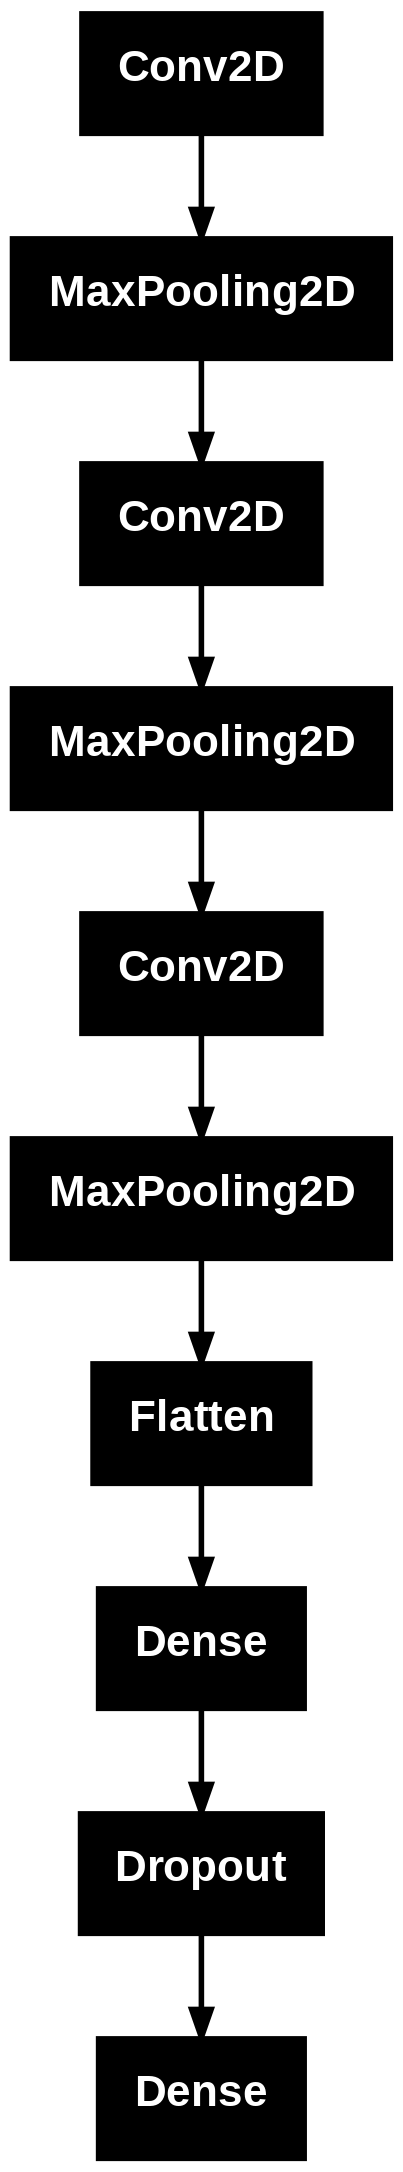

In [26]:
keras.utils.plot_model(model)


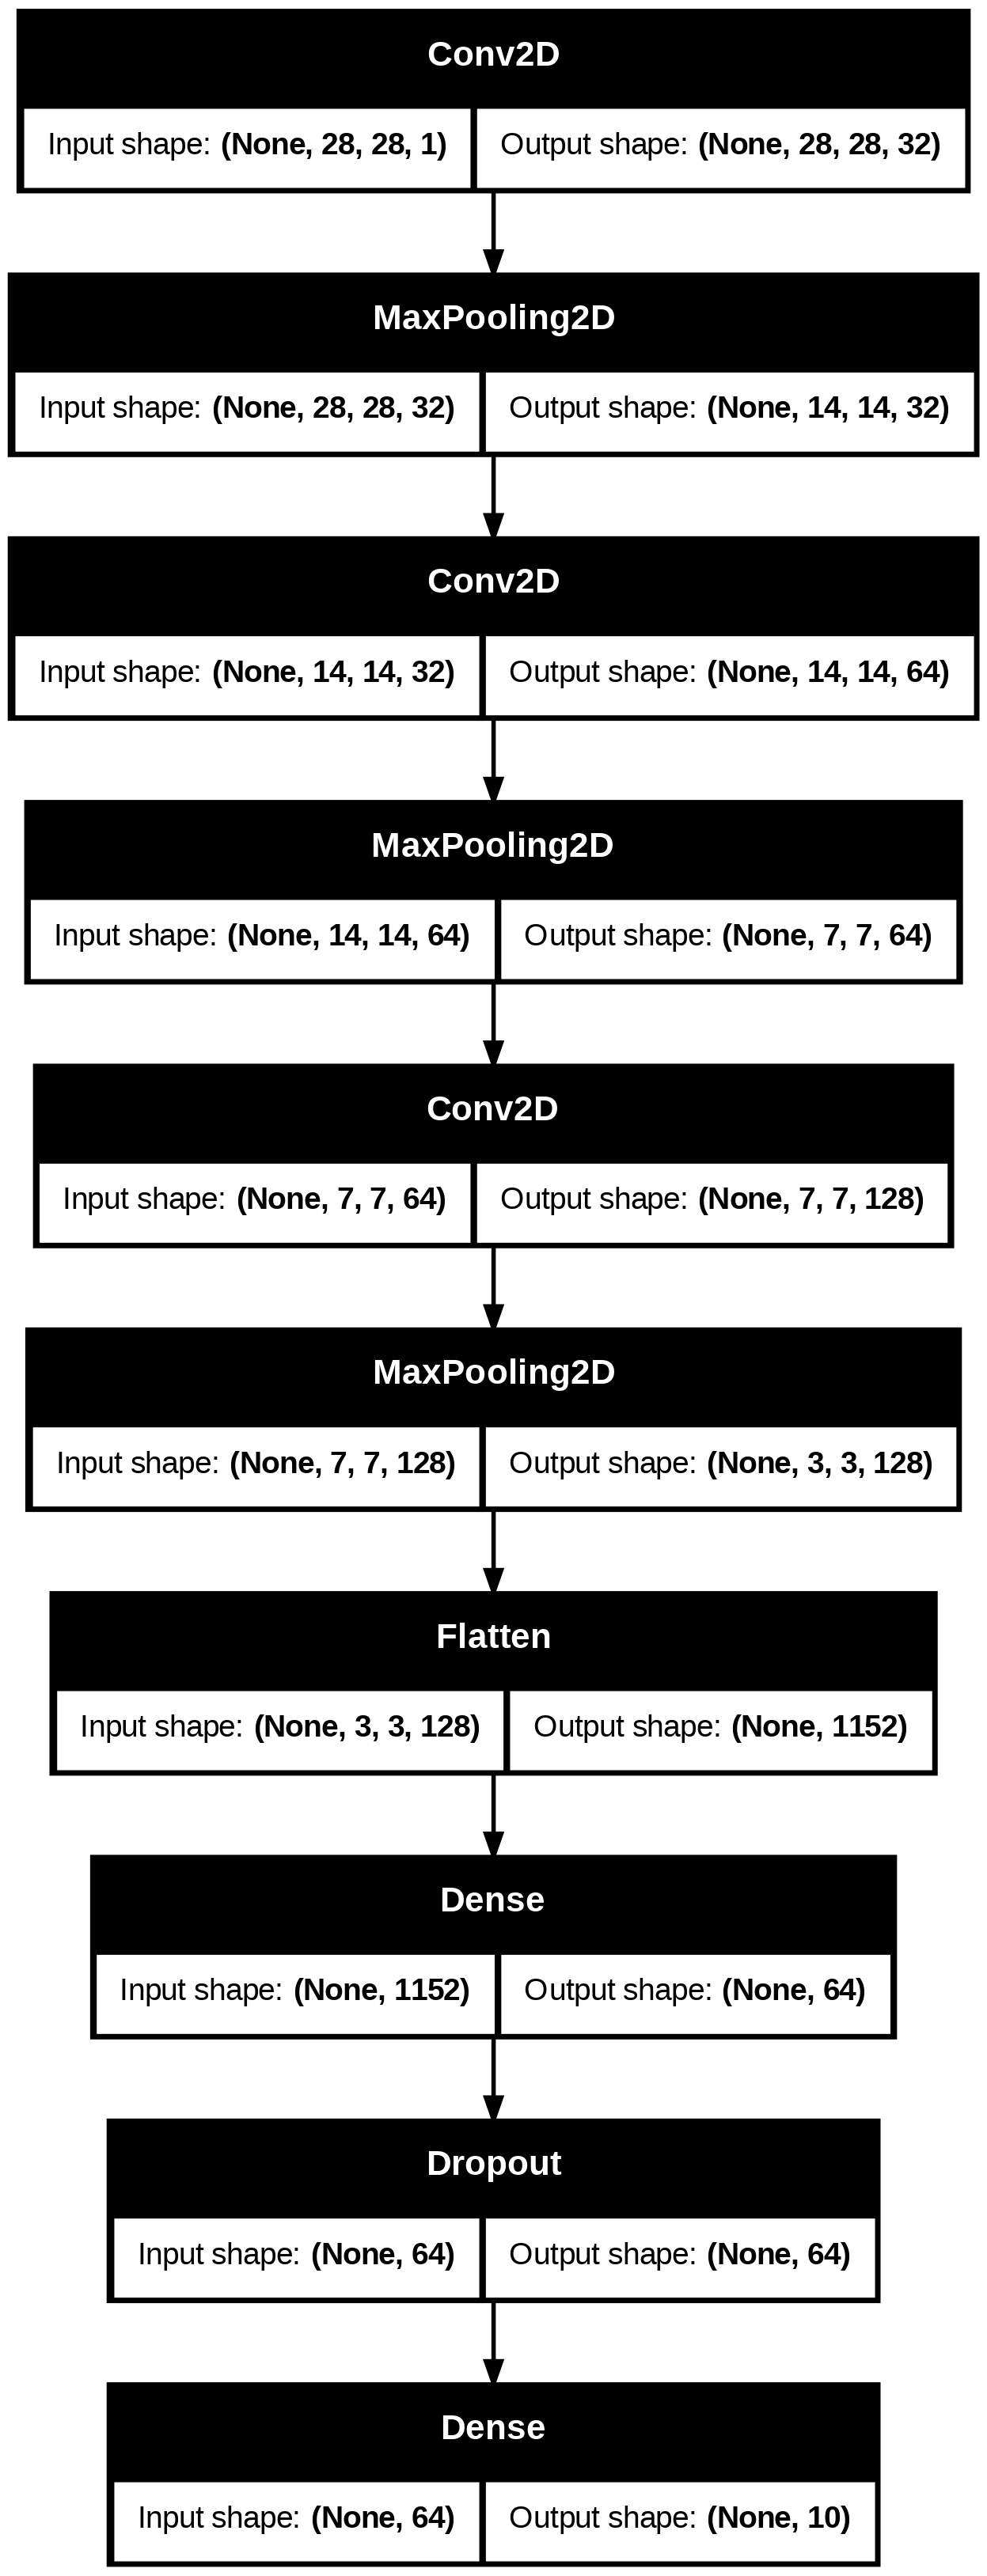

In [27]:
keras.utils.plot_model(model, show_shapes=True)


## 모델 컴파일과 훈련


In [28]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
              # 현재 텐서플로 버전에서는 최대 풀링에 대한 결정적인 XLA 구현이 없기 때문에
              # enable_op_determinism() 호출로 인해 오류가 발생합니다.
              # 이를 피하기 위해 jit_compile 옵션을 False로 지정합니다.
              # https://github.com/tensorflow/tensorflow/issues/69417
              jit_compile=False)
checkpoint_cb = keras.callbacks.ModelCheckpoint('15_combo_light_3conv_dense64.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=15,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])




Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7796 - loss: 0.6098 - val_accuracy: 0.8655 - val_loss: 0.3645
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8633 - loss: 0.3806 - val_accuracy: 0.8901 - val_loss: 0.2939
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8848 - loss: 0.3219 - val_accuracy: 0.8990 - val_loss: 0.2723
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8982 - loss: 0.2861 - val_accuracy: 0.9070 - val_loss: 0.2558
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9089 - loss: 0.2576 - val_accuracy: 0.9103 - val_loss: 0.2482
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9162 - loss: 0.2329 - val_accuracy: 0.9107 - val_loss: 0.2411
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9232 - loss: 0.2155 - val_accuracy: 0.9106 - val_loss: 0.2463
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9281 - loss: 0

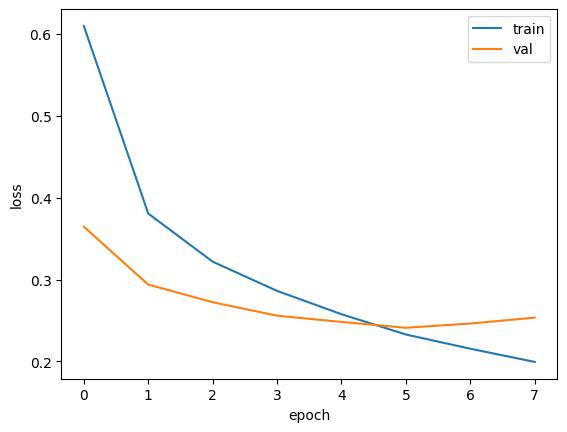

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()


## Accuracy Curve

Train accuracy와 validation accuracy를 비교하여 일반화 성능과 과적합 여부를 확인합니다.



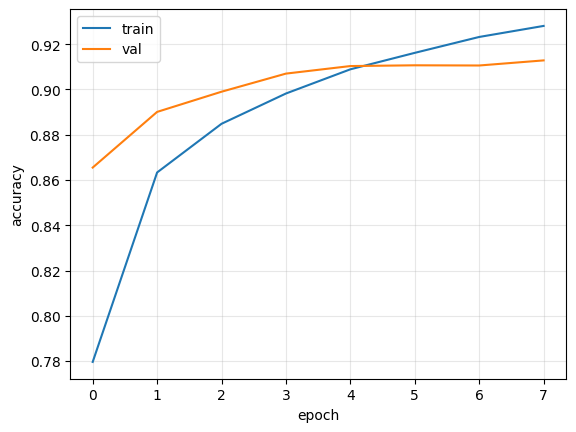

In [30]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train', 'val'])
plt.grid(True, alpha=0.3)
plt.show()




In [31]:
model.evaluate(val_scaled, val_target)


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9107 - loss: 0.2411


[0.24109655618667603, 0.9106666445732117]

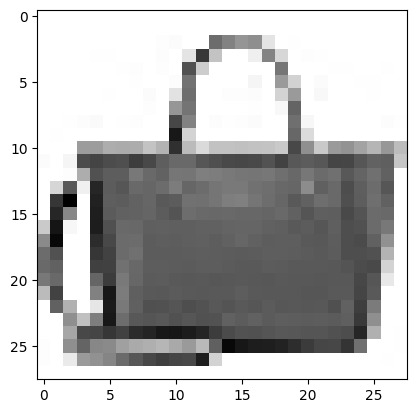

In [32]:
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()


In [33]:
preds = model.predict(val_scaled[0:1])
print(preds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
[[4.5318029e-15 1.5741569e-23 8.0792616e-18 1.2925994e-18 1.1235016e-17
  7.9272581e-18 9.6119912e-16 7.3594197e-19 1.0000000e+00 6.1359004e-20]]


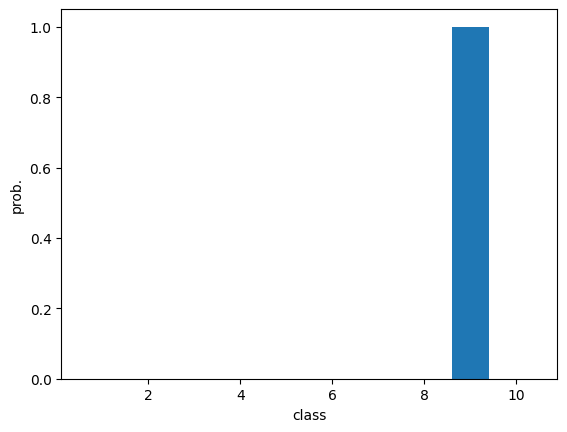

In [34]:
plt.bar(range(1, 11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()


In [35]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
           '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']


In [36]:
import numpy as np

print(classes[np.argmax(preds)])


가방


In [37]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0


In [38]:
model.evaluate(test_scaled, test_target)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9050 - loss: 0.2576


[0.2576175332069397, 0.9049999713897705]

## Confusion Matrix

Test set에서 어떤 class끼리 혼동되는지 확인합니다.



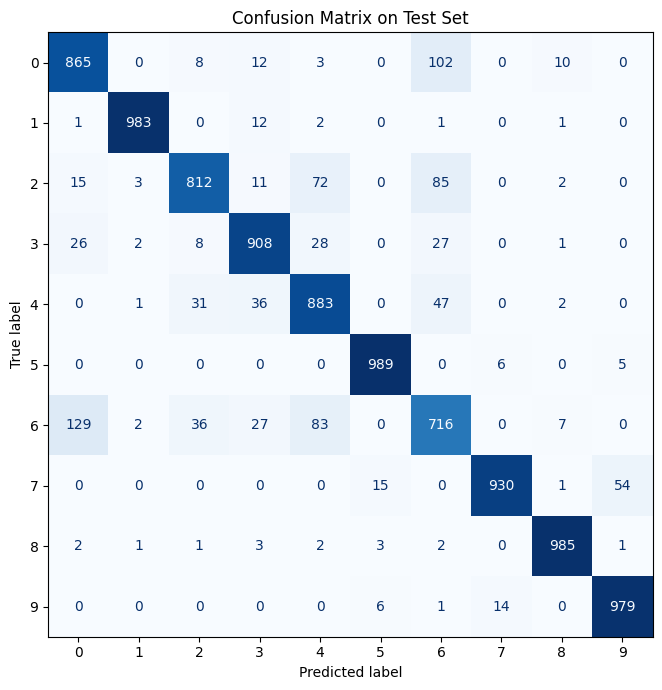

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

pred_labels = model.predict(test_scaled, verbose=0).argmax(axis=1)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(
    test_target,
    pred_labels,
    display_labels=range(10),
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()




## 실험 결과 저장

집계 노트북에서 비교할 수 있도록 validation/test 성능과 loss history를 JSON 파일로 저장합니다.



In [40]:
import json
import os

val_loss, val_accuracy = model.evaluate(val_scaled, val_target, verbose=0)
test_loss, test_accuracy = model.evaluate(test_scaled, test_target, verbose=0)

try:
    RESULT_DIR = '/content/drive/MyDrive/CNN_fashion_results'
    os.makedirs(RESULT_DIR, exist_ok=True)
except Exception:
    RESULT_DIR = './CNN_fashion_results'
    os.makedirs(RESULT_DIR, exist_ok=True)

result = {
    'experiment_name': model.name,
    'parameter_count': int(model.count_params()),
    'epochs_ran': len(history.history['loss']),
    'best_val_loss': float(min(history.history['val_loss'])),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'final_val_loss': float(val_loss),
    'final_val_accuracy': float(val_accuracy),
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
    'train_loss_history': [float(x) for x in history.history['loss']],
    'val_loss_history': [float(x) for x in history.history['val_loss']],
    'train_accuracy_history': [float(x) for x in history.history['accuracy']],
    'val_accuracy_history': [float(x) for x in history.history['val_accuracy']],
}

result_path = os.path.join(RESULT_DIR, f'{model.name}.json')
with open(result_path, 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print('Saved result:', result_path)
print(result)




Saved result: /content/drive/MyDrive/CNN_fashion_results/exp15_combo_light_3conv_dense64.json
{'experiment_name': 'exp15_combo_light_3conv_dense64', 'parameter_count': 167114, 'epochs_ran': 8, 'best_val_loss': 0.24109655618667603, 'best_val_accuracy': 0.9128333330154419, 'final_val_loss': 0.24109655618667603, 'final_val_accuracy': 0.9106666445732117, 'test_loss': 0.2576175332069397, 'test_accuracy': 0.9049999713897705, 'train_loss_history': [0.6098348498344421, 0.3806414008140564, 0.32185035943984985, 0.28613734245300293, 0.25763899087905884, 0.23286676406860352, 0.2154865562915802, 0.19935829937458038], 'val_loss_history': [0.3645218014717102, 0.29385778307914734, 0.2723102271556854, 0.25584307312965393, 0.24822497367858887, 0.24109655618667603, 0.24625132977962494, 0.25348126888275146], 'train_accuracy_history': [0.7796458601951599, 0.8633333444595337, 0.8848333358764648, 0.8982083201408386, 0.9088958501815796, 0.9161666631698608, 0.9231874942779541, 0.9280624985694885], 'val_accurac